In [ ]:
# https://data.cityofchicago.org/resource/wrvz-psew.json

In [ ]:
import requests
import pandas as pd

url = "https://data.cityofchicago.org/resource/wrvz-psew.json"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    df = pd.DataFrame(data)
    print("Data retrieved successfully and converted to Pandas DataFrame.")
else:
    print(f"Error {response.status_code}: Unable to retrieve data.")
    print(response.text)

Data retrieved successfully and converted to Pandas DataFrame.


In [ ]:
df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,fare,tips,tolls,extras,...,dropoff_community_area,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location,:@computed_region_vrxf_vc4k,pickup_census_tract,dropoff_census_tract
0,c6510d4f82541cfacf8c20cab44fbb7c0b2c5efe,89fc6b1f0628f328ccd1021fcf4e7318bb2f9962da9259...,2023-12-31T23:45:00.000,2024-01-01T00:15:00.000,1280,8.19,22.5,3,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,e9a66ddcc78cfd79f419165314cbe5ee380f16c3,8efe74ab61de459003dcedd85c637ce11bba19bac633cd...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,390,0.09,34.86,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ee7cce18a4b24e080366930ab5ec72d1aeb6556c,adb1cb74113851b651b474182fbe95a9663783779db8cc...,2023-12-31T23:45:00.000,2024-01-01T00:00:00.000,1310,18.23,60,0,0,0,...,76,41.874005383,-87.66351755,"{'type': 'Point', 'coordinates': [-87.66351754...",41.980264315,-87.913624596,"{'type': 'Point', 'coordinates': [-87.91362459...",29,NaN,NaN
3,4f2165874756524b46ba42d39db0f5c59e1c159d,f9f12d79733b1fa7934f8d9bd17ca1927f3c99ded1640b...,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,9,0,3.25,0,0,47,...,33,41.857183858,-87.620334624,"{'type': 'Point', 'coordinates': [-87.62033462...",41.857183858,-87.620334624,"{'type': 'Point', 'coordinates': [-87.62033462...",34,NaN,NaN
4,ac9c9cd082dbdbfb67fc062dcb74ed713820e47f,75cf3a53aae5e5858361a7ca64f75d3407dc0a44d7bc42...,2023-12-31T23:45:00.000,2023-12-31T23:45:00.000,439,0.98,6.5,4,0,1,...,32,41.878865584,-87.625192142,"{'type': 'Point', 'coordinates': [-87.62519214...",41.878865584,-87.625192142,"{'type': 'Point', 'coordinates': [-87.62519214...",38,NaN,NaN


In [ ]:
# prompt: check data

# Check for missing values
missing_values = df.isnull().sum()

# Print the number of missing values in each column
print(missing_values)

# Check the data types of each column
data_types = df.dtypes

# Print the data types of each column
print(data_types)

# Check the shape of the dataframe
shape = df.shape

# Print the number of rows and columns
print(shape)


trip_id                          0
taxi_id                          0
trip_start_timestamp             0
trip_end_timestamp               0
trip_seconds                     0
trip_miles                       0
fare                             1
tips                             1
tolls                            1
extras                           1
trip_total                       1
payment_type                     0
company                          0
pickup_community_area           28
dropoff_community_area          89
pickup_centroid_latitude        28
pickup_centroid_longitude       28
pickup_centroid_location        28
dropoff_centroid_latitude       86
dropoff_centroid_longitude      86
dropoff_centroid_location       86
:@computed_region_vrxf_vc4k     28
pickup_census_tract            751
dropoff_census_tract           764
dtype: int64
trip_id                        object
taxi_id                        object
trip_start_timestamp           object
trip_end_timestamp             ob

In [ ]:
# prompt: trip_id                        object taxi_id                        object trip_start_timestamp           object trip_end_timestamp             object trip_seconds                   object trip_miles                     object fare                           object tips                           object tolls                          object extras                         object trip_total

# Get the column names
column_names = df.columns.tolist()

# Print the column names
print(column_names)


['trip_id', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'fare', 'tips', 'tolls', 'extras', 'trip_total', 'payment_type', 'company', 'pickup_community_area', 'dropoff_community_area', 'pickup_centroid_latitude', 'pickup_centroid_longitude', 'pickup_centroid_location', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'dropoff_centroid_location', ':@computed_region_vrxf_vc4k', 'pickup_census_tract', 'dropoff_census_tract']


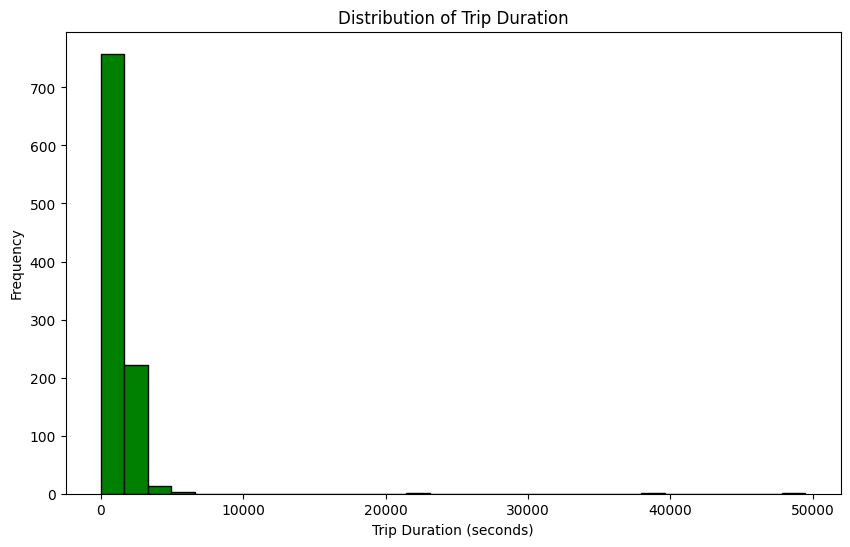

In [ ]:
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Convert timestamp columns to datetime objects
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])

# Calculate trip duration in seconds
df['trip_duration'] = (df['trip_end_timestamp'] - df['trip_start_timestamp']).dt.total_seconds()

# Plot histogram of trip duration
plt.figure(figsize=(10, 6))
plt.hist(df['trip_duration'].dropna(), bins=30, color='green', edgecolor='black')
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
!pip install -q dash

In [ ]:
import dash
from dash import dcc, html
import pandas as pd
import plotly.express as px

# Assuming df is your DataFrame
# Convert timestamp columns to datetime objects
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'])
df['trip_end_timestamp'] = pd.to_datetime(df['trip_end_timestamp'])

# Calculate trip duration in seconds
df['trip_duration'] = (df['trip_end_timestamp'] - df['trip_start_timestamp']).dt.total_seconds()

# Convert latitude and longitude columns to numeric
df['pickup_centroid_latitude'] = pd.to_numeric(df['pickup_centroid_latitude'], errors='coerce')
df['pickup_centroid_longitude'] = pd.to_numeric(df['pickup_centroid_longitude'], errors='coerce')

# Create a scatter map plot using plotly express
scatter_map = px.scatter_mapbox(
    df,
    lat='pickup_centroid_latitude',
    lon='pickup_centroid_longitude',
    hover_name='trip_id',
    title='Pickup Locations of Taxi Trips',
    mapbox_style='carto-positron',
    zoom=10
)

# Create a histogram of trip distances
histogram = px.histogram(
    df,
    x='trip_miles',
    title='Distribution of Trip Distances',
    labels={'trip_miles': 'Trip Distance (miles)', 'count': 'Frequency'}
)

# Create a scatter plot of trip miles vs. fare
scatter_plot = px.scatter(
    df,
    x='trip_miles',
    y='fare',
    title='Scatter Plot of Trip Miles vs. Fare',
    labels={'trip_miles': 'Trip Distance (miles)', 'fare': 'Fare'}
)

# Create a scatter plot of trip duration
scatter_duration = px.scatter(
    df,
    x='trip_duration',
    y='fare',
    title='Scatter Plot of Trip Duration vs. Fare',
    labels={'trip_duration': 'Trip Duration (seconds)', 'fare': 'Fare'}
)

# Dash app
app = dash.Dash(__name__)

# Define the layout of the dashboard
app.layout = html.Div([
    html.H1("Taxi Trip Data Dashboard"),

    dcc.Graph(figure=scatter_map, id='scatter_map'),

    dcc.Graph(figure=histogram, id='histogram'),

    dcc.Graph(figure=scatter_plot, id='scatter_plot'),

    dcc.Graph(figure=scatter_duration, id='scatter_duration'),
])

if __name__ == '__main__':
    app.run_server(debug=True)

<IPython.core.display.Javascript object>

In [ ]:
# Create a time series plot of the number of trips over time
time_series = px.line(
    df.groupby(df['trip_start_timestamp'].dt.date).size().reset_index(name='Number of Trips'),
    x='trip_start_timestamp',
    y='Number of Trips',
    title='Number of Trips Over Time'
)

In [ ]:
time_series

In [ ]:
# Create a pie chart of payment types
payment_pie_chart = px.pie(
    df['payment_type'].value_counts().reset_index(),
    names='index',
    values='payment_type',
    title='Distribution of Payment Types'
)

In [ ]:
payment_pie_chart

In [ ]:
# Create a bar chart of the number of trips by taxi company
bar_chart_taxi_company = px.bar(
    df['company'].value_counts().reset_index(),
    x='index',
    y='company',
    title='Number of Trips by Taxi Company',
    labels={'index': 'Taxi Company', 'company': 'Number of Trips'}
)


In [ ]:
bar_chart_taxi_company

In [ ]:
from datetime import timedelta

# Simulated data for driver tracking
import random

random.seed(42)

def generate_simulated_data():
    num_drivers = 5
    start_date = pd.to_datetime('2022-01-01')
    end_date = pd.to_datetime('2022-01-10')
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')

    data = []
    for driver_id in range(1, num_drivers + 1):
        for date in date_range:
            data.append({
                'driver_id': driver_id,
                'timestamp': (date + timedelta(hours=random.randint(0, 23), minutes=random.randint(0, 59))).strftime('%Y-%m-%d %H:%M:%S'),
                'latitude': random.uniform(41.8, 42),
                'longitude': random.uniform(-87.7, -87.6),
            })

    return pd.DataFrame(data)

df_drivers = generate_simulated_data()

# Dash app
app = dash.Dash(__name__)

# Create a scatter map plot showing the movement of drivers over time
scatter_driver_map = px.scatter_mapbox(
    df_drivers,
    lat='latitude',
    lon='longitude',
    color='driver_id',
    hover_name='driver_id',
    animation_frame='timestamp',
    title='Driver Movement Over Time',
    mapbox_style='carto-positron',
    zoom=10
)

# Define the layout of the dashboard
app.layout = html.Div([
    html.H1("Driver Tracking Dashboard"),

    dcc.Graph(figure=scatter_driver_map, id='scatter_driver_map'),
])

if __name__ == '__main__':
    app.run_server(debug=True)


<IPython.core.display.Javascript object>